In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("adult_with_headers.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(24)

In [6]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.585549,13.637984,17.0,28.0,37.0,48.0,90.0
fnlwgt,32537.0,189780.848511,105556.471009,12285.0,117827.0,178356.0,236993.0,1484705.0
education_num,32537.0,10.081815,2.571633,1.0,9.0,10.0,12.0,16.0
capital_gain,32537.0,1078.443741,7387.957424,0.0,0.0,0.0,0.0,99999.0
capital_loss,32537.0,87.368227,403.101833,0.0,0.0,0.0,0.0,4356.0
hours_per_week,32537.0,40.440329,12.346889,1.0,40.0,40.0,45.0,99.0


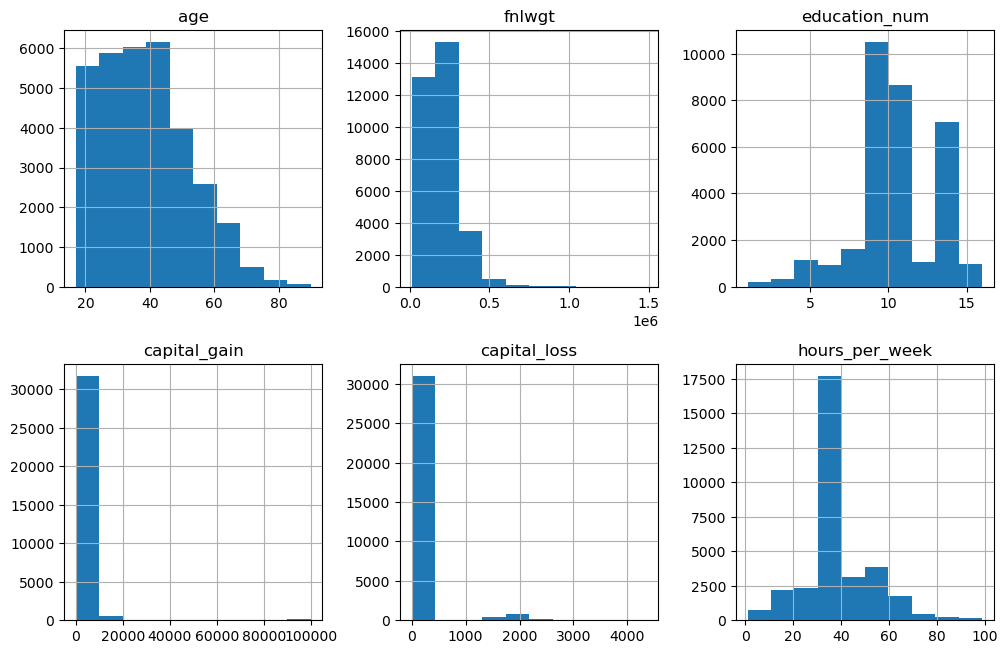

In [8]:
df[df.describe().columns].hist(figsize=(12,12), layout=(3,3));
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [10]:
sc = StandardScaler()
mm = MinMaxScaler()
le = LabelEncoder()

In [11]:
df[['age', 'hours_per_week']] = sc.fit_transform(
    df[['age', 'hours_per_week']]
)

In [12]:
df_minmax = df.copy()
df_minmax[['fnlwgt','capital_gain','capital_loss','education_num']] = \
    mm.fit_transform(df_minmax[['fnlwgt','capital_gain','capital_loss','education_num']])
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030390,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,-0.035664,United-States,<=50K
1,0.836973,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,-2.222483,United-States,<=50K
2,-0.042936,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,-0.035664,United-States,<=50K
3,1.056950,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,-0.035664,United-States,<=50K
4,-0.776193,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,-0.035664,Cuba,<=50K


- Standard Scaling is applied to features with relatively stable distributions, while Min-Max Scaling is applied to features with large ranges to normalize them between 0 and 1.

- Standard Scaling:
Standard Scaling changes the data so that the average becomes 0 and the spread becomes 1. It is useful when features are roughly normally distributed and when models work better with centered data.

- Min-Max Scaling:
Min-Max Scaling converts values into a fixed range between 0 and 1. It is useful when features have very different scales or when models require values within a specific range.

In [13]:
list1 = []
for i in df.select_dtypes('object').columns:
    if df[i].nunique() > 5:
        df[i] = le.fit_transform(df[i])
    else:
        list1.append(i)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030390,7,77516,9,13,4,1,1,White,Male,2174,0,-0.035664,39,<=50K
1,0.836973,6,83311,9,13,2,4,0,White,Male,0,0,-2.222483,39,<=50K
2,-0.042936,4,215646,11,9,0,6,1,White,Male,0,0,-0.035664,39,<=50K
3,1.056950,4,234721,1,7,2,6,0,Black,Male,0,0,-0.035664,39,<=50K
4,-0.776193,4,338409,9,13,2,10,5,Black,Female,0,0,-0.035664,5,<=50K


In [14]:
list1

['race', 'sex', 'income']

In [15]:
race = pd.get_dummies(df['race'], drop_first=True)
race.head()

,Asian-Pac-Islander,Black,Other,White
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,True,False,False
4,False,True,False,False


In [16]:
sex = pd.get_dummies(df['sex'], drop_first=True)
sex.head()

,Male
0,True
1,True
2,True
3,True
4,False


In [17]:
income = pd.get_dummies(df['income'], drop_first=True)
income.head()

,>50K
0,False
1,False
2,False
3,False
4,False


In [18]:
df = pd.concat([df, race, sex, income], axis=1)
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,capital_loss,hours_per_week,native_country,income,Asian-Pac-Islander,Black,Other,White,Male,>50K
0,0.030390,7,77516,9,13,4,1,1,White,Male,...,0,-0.035664,39,<=50K,False,False,False,True,True,False
1,0.836973,6,83311,9,13,2,4,0,White,Male,...,0,-2.222483,39,<=50K,False,False,False,True,True,False
2,-0.042936,4,215646,11,9,0,6,1,White,Male,...,0,-0.035664,39,<=50K,False,False,False,True,True,False
3,1.056950,4,234721,1,7,2,6,0,Black,Male,...,0,-0.035664,39,<=50K,False,True,False,False,True,False
4,-0.776193,4,338409,9,13,2,10,5,Black,Female,...,0,-0.035664,5,<=50K,False,True,False,False,False,False


In [19]:
df = df.drop(['race', 'sex', 'income'], axis=1)
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,Asian-Pac-Islander,Black,Other,White,Male,>50K
0,0.030390,7,77516,9,13,4,1,1,2174,0,-0.035664,39,False,False,False,True,True,False
1,0.836973,6,83311,9,13,2,4,0,0,0,-2.222483,39,False,False,False,True,True,False
2,-0.042936,4,215646,11,9,0,6,1,0,0,-0.035664,39,False,False,False,True,True,False
3,1.056950,4,234721,1,7,2,6,0,0,0,-0.035664,39,False,True,False,False,True,False
4,-0.776193,4,338409,9,13,2,10,5,0,0,-0.035664,5,False,True,False,False,False,False


**One-Hot Encoding**

**Pros:**

* Easy to understand
* Works well for categorical data
* No order is assumed between categories

**Cons:**

* Creates many new columns
* Increases dataset size
* Can slow down the model if too many categories

**Label Encoding**

**Pros:**

* Simple and fast
* Uses less memory
* Good for columns with many categories

**Cons:**

* Assigns numbers that may look like order
* Not suitable for categories without natural ranking

In [20]:
df['capital_gain'] = np.log(df['capital_gain'])
df.head()

C:\Users\Bibhuprasad Das\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,Asian-Pac-Islander,Black,Other,White,Male,>50K
0,0.030390,7,77516,9,13,4,1,1,7.684324,0,-0.035664,39,False,False,False,True,True,False
1,0.836973,6,83311,9,13,2,4,0,-inf,0,-2.222483,39,False,False,False,True,True,False
2,-0.042936,4,215646,11,9,0,6,1,-inf,0,-0.035664,39,False,False,False,True,True,False
3,1.056950,4,234721,1,7,2,6,0,-inf,0,-0.035664,39,False,True,False,False,True,False
4,-0.776193,4,338409,9,13,2,10,5,-inf,0,-0.035664,5,False,True,False,False,False,False


In [21]:
df['capital_gain'] = df['capital_gain'].replace(-np.inf, np.nan)
min_value = df['capital_gain'].min()
df['capital_gain'] = df['capital_gain'].fillna(min_value)
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,Asian-Pac-Islander,Black,Other,White,Male,>50K
0,0.030390,7,77516,9,13,4,1,1,7.684324,0,-0.035664,39,False,False,False,True,True,False
1,0.836973,6,83311,9,13,2,4,0,4.736198,0,-2.222483,39,False,False,False,True,True,False
2,-0.042936,4,215646,11,9,0,6,1,4.736198,0,-0.035664,39,False,False,False,True,True,False
3,1.056950,4,234721,1,7,2,6,0,4.736198,0,-0.035664,39,False,True,False,False,True,False
4,-0.776193,4,338409,9,13,2,10,5,4.736198,0,-0.035664,5,False,True,False,False,False,False


The "capital_gain" column is highly skewed, with many small values and a few very large ones. Applying a log transformation reduces this skewness and makes the data more balanced, which helps machine learning models perform better.

In [22]:
from sklearn.ensemble import IsolationForest

In [23]:
iso = IsolationForest(contamination=0.1)
outlier_labels = iso.fit_predict(df)
outlier_labels

array([1, 1, 1, ..., 1, 1, 1], shape=(32537,))

In [24]:
mask = outlier_labels != -1
df = df[mask]
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,Asian-Pac-Islander,Black,Other,White,Male,>50K
0,0.030390,7,77516,9,13,4,1,1,7.684324,0,-0.035664,39,False,False,False,True,True,False
1,0.836973,6,83311,9,13,2,4,0,4.736198,0,-2.222483,39,False,False,False,True,True,False
2,-0.042936,4,215646,11,9,0,6,1,4.736198,0,-0.035664,39,False,False,False,True,True,False
3,1.056950,4,234721,1,7,2,6,0,4.736198,0,-0.035664,39,False,True,False,False,True,False
5,-0.116262,4,284582,12,14,2,4,5,4.736198,0,-0.035664,39,False,False,False,True,False,False


Outliers are extreme values that can negatively affect model performance. They may cause the model to learn incorrect patterns. Removing outliers helps the model focus on normal data and improves accuracy and reliability.

In [25]:
#!pip install ppscore

In [26]:
import ppscore as pps

In [27]:
pp_score = pps.matrix(df)
pp_score

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.000000e+00,predict_itself,True,None,0.000000,1.000000,None
1,age,workclass,0.000000e+00,regression,True,mean absolute error,0.693400,0.812814,DecisionTreeRegressor()
2,age,fnlwgt,0.000000e+00,regression,True,mean absolute error,75688.859800,76757.601109,DecisionTreeRegressor()
3,age,education,0.000000e+00,regression,True,mean absolute error,2.604000,2.662690,DecisionTreeRegressor()
4,age,education_num,0.000000e+00,regression,True,mean absolute error,1.773800,1.810060,DecisionTreeRegressor()
...,...,...,...,...,...,...,...,...,...
319,>50K,Black,4.891216e-07,classification,True,weighted F1,0.910340,0.910340,DecisionTreeClassifier()
320,>50K,Other,7.452031e-06,classification,True,weighted F1,0.994603,0.994603,DecisionTreeClassifier()
321,>50K,White,3.001583e-07,classification,True,weighted F1,0.887793,0.887793,DecisionTreeClassifier()
322,>50K,Male,0.000000e+00,classification,True,weighted F1,0.571200,0.553319,DecisionTreeClassifier()


In [28]:
pp_corr = pd.pivot_table(pp_score, index='x', columns='y', values='ppscore')
pp_corr

y,>50K,Asian-Pac-Islander,Black,Male,Other,White,age,capital_gain,capital_loss,education,education_num,fnlwgt,hours_per_week,marital_status,native_country,occupation,relationship,workclass
x,,,,,,,,,,,,,,,,,,
>50K,1.000000e+00,0.000000,4.891216e-07,0.000000,0.000007,3.001583e-07,0.030595,0.0,0.0,0.0,0.027645,0.000000,0.0,0.000512,0.0,0.000000,0.000000,0.000000
Asian-Pac-Islander,1.320004e-07,1.000000,4.891216e-07,0.000000,0.000007,1.001859e-01,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
Black,1.320004e-07,0.000000,1.000000e+00,0.084241,0.000007,8.548979e-01,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
Male,1.320004e-07,0.000000,4.891216e-07,1.000000,0.000007,3.001583e-07,0.000490,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.134470,0.000000
Other,1.320004e-07,0.000000,4.891216e-07,0.000000,1.000000,7.554289e-02,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
White,1.320004e-07,0.000000,8.379056e-01,0.000000,0.000007,1.000000e+00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
age,8.467541e-04,0.000000,4.891216e-07,0.000000,0.000007,3.001583e-07,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.195824,0.0,0.000000,0.047910,0.000000
capital_gain,3.004067e-01,0.000000,4.891216e-07,0.000000,0.000007,3.001583e-07,0.008410,1.0,0.0,0.0,0.006210,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
capital_loss,1.125191e-01,0.000000,4.891216e-07,0.000000,0.000007,3.001583e-07,0.000000,0.0,1.0,0.0,0.001047,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000


- The correlation matrix shows linear relationships only between numerical variables. It does not work well for categorical variables.
- PPS identifies both linear and non-linear relationships and works for numerical as well as categorical variables. Therefore, PPS gives deeper insights compared to the correlation matrix.

<Axes: xlabel='y', ylabel='x'>

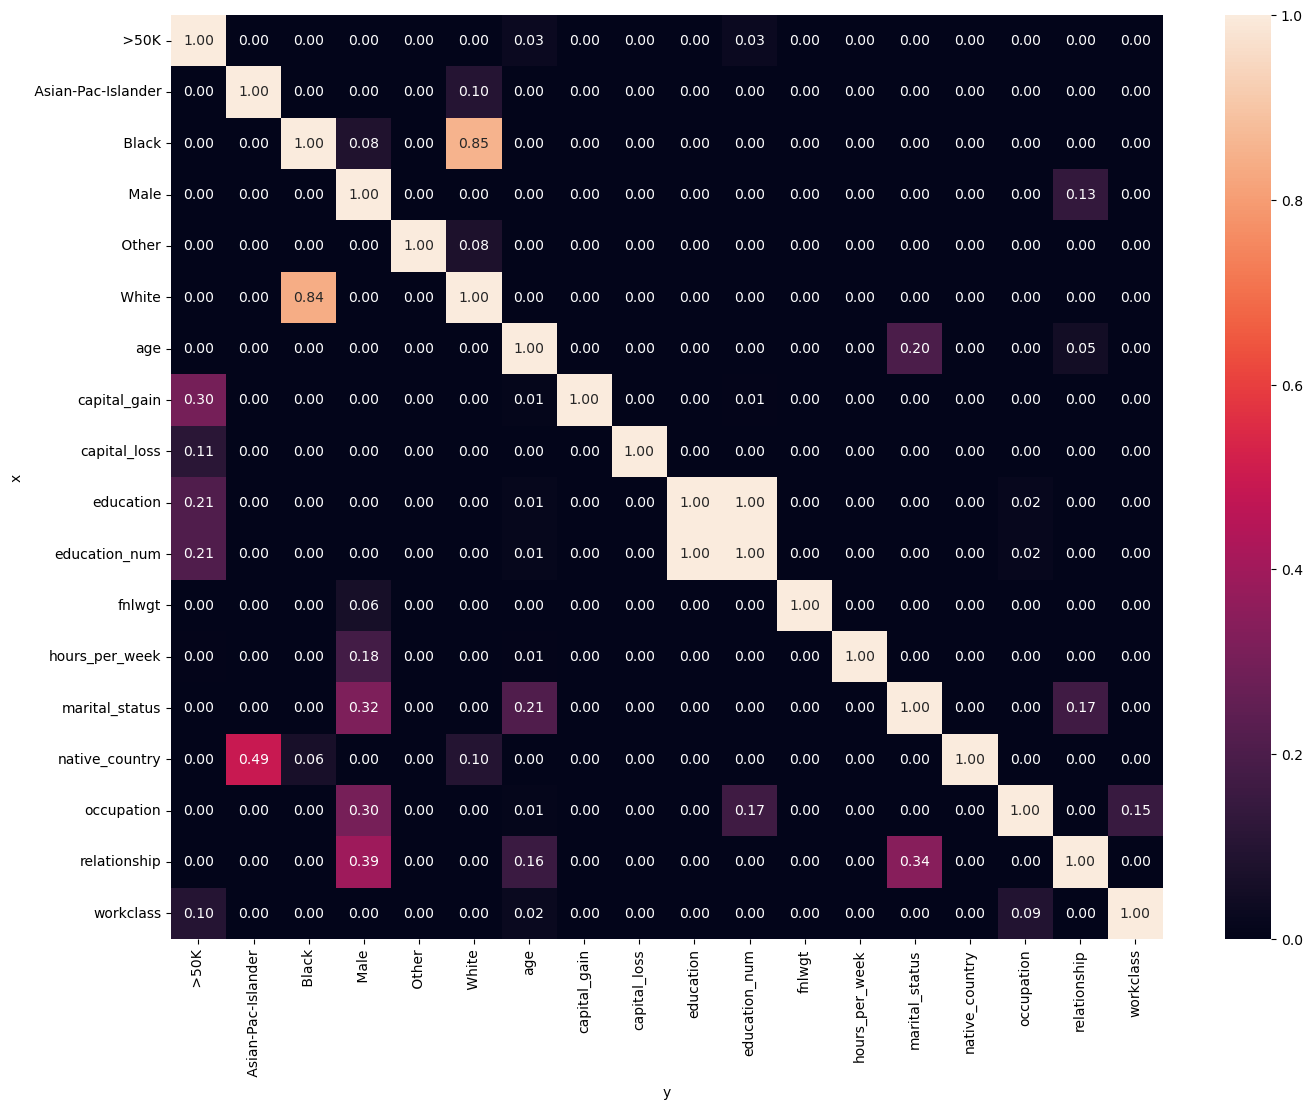

In [29]:
plt.figure(figsize=(16,12))
sns.heatmap(pp_corr,annot=True,fmt=".2f")

In [30]:
corr = df.corr()
corr

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,Asian-Pac-Islander,Black,Other,White,Male,>50K
age,1.000000,0.033042,-0.078691,0.009503,0.060373,-0.311896,-0.012235,-0.298845,0.113976,0.040656,0.098316,0.025974,-0.012650,-0.065582,-0.033671,0.074362,0.116301,0.242774
workclass,0.033042,1.000000,-0.015626,0.003868,0.034908,-0.050007,0.216366,-0.084527,0.037230,0.011493,0.121450,-0.005183,0.006621,0.000180,0.004402,0.001337,0.080944,0.046457
fnlwgt,-0.078691,-0.015626,1.000000,-0.024338,-0.043508,0.033139,-0.000529,0.007692,-0.007107,-0.011442,-0.024306,-0.070058,-0.026007,0.076482,0.005432,-0.042750,0.025894,-0.011143
education,0.009503,0.003868,-0.024338,1.000000,0.325320,-0.026311,-0.029436,0.003964,0.027203,0.019522,0.044798,0.061585,0.000706,0.038859,0.008941,-0.037962,-0.049337,0.065875
education_num,0.060373,0.034908,-0.043508,0.325320,1.000000,-0.051919,0.105175,-0.096786,0.133685,0.075776,0.147038,0.073968,0.021772,-0.047967,-0.005088,0.046982,-0.001127,0.324931
marital_status,-0.311896,-0.050007,0.033139,-0.026311,-0.051919,1.000000,-0.000817,0.199942,-0.069645,-0.038177,-0.191582,-0.026233,0.010936,0.094172,0.017205,-0.090148,-0.126628,-0.197140
occupation,-0.012235,0.216366,-0.000529,-0.029436,0.105175,-0.000817,1.000000,-0.071184,0.023396,0.016445,0.063894,0.002699,-0.004443,0.014067,0.002362,-0.011890,0.070697,0.072500
relationship,-0.298845,-0.084527,0.007692,0.003964,-0.096786,0.199942,-0.071184,1.000000,-0.123339,-0.085909,-0.260094,0.011506,-0.014645,0.125216,-0.000030,-0.114531,-0.574432,-0.284101
capital_gain,0.113976,0.037230,-0.007107,0.027203,0.133685,-0.069645,0.023396,-0.123339,1.000000,-0.054162,0.096238,0.037355,-0.018896,-0.063273,-0.015686,0.068449,0.096955,0.286691
capital_loss,0.040656,0.011493,-0.011442,0.019522,0.075776,-0.038177,0.016445,-0.085909,-0.054162,1.000000,0.060889,0.028663,-0.013967,-0.045280,-0.011594,0.051179,0.063256,0.137920


<Axes: >

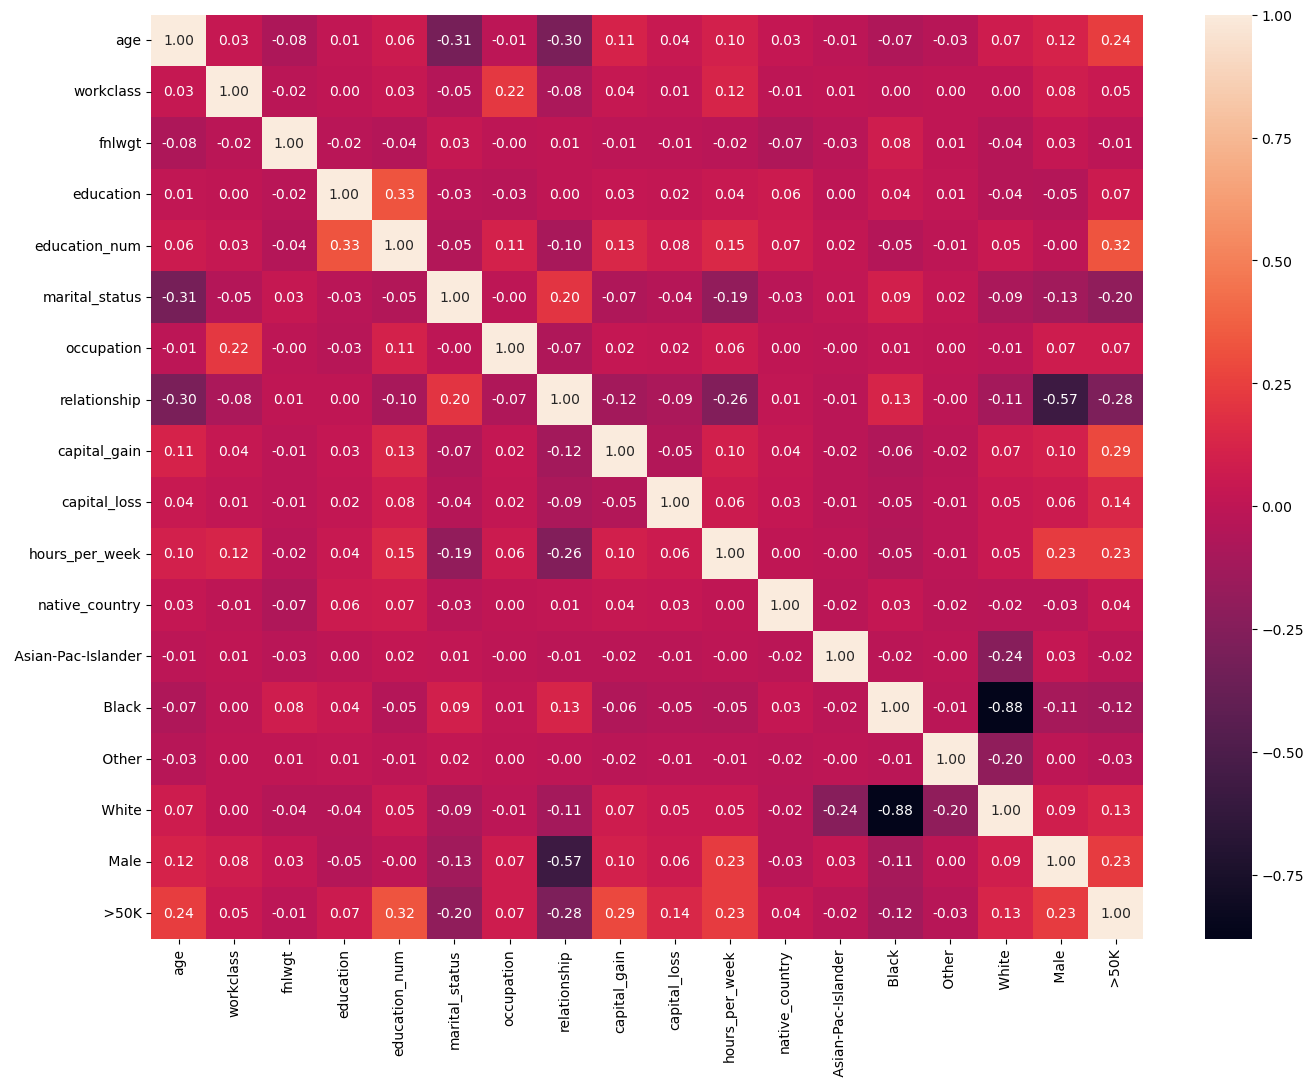

In [31]:
plt.figure(figsize=(16,12))
sns.heatmap(corr,annot=True,fmt=".2f")

**Comparison and Discussion**

- Both correlation and PPS show that features like education_num, capital_gain, and age influence income (>50K). However, correlation only measures linear relationships, while PPS shows actual predictive power.

- Some features such as workclass and native_country have very low correlation and also low predictive power in PPS.

- The correlation matrix shows a strong relationship between education and education_num, which is expected since they represent similar information.

- PPS reveals that features like relationship and marital_status have noticeable predictive power for income, even though their correlation values are not very high. This shows that PPS can capture more complex relationships than correlation.